In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# -----------------------------
# 1. Cargar base de datos
# -----------------------------
df = pd.read_csv("../data/global_crisis_data.csv")

study_vars = ["inflation", "gdp_growth", "unemployment", "fed_funds_rate"]

print("Dimensión base original:", df.shape)
print(df[study_vars].head())

Dimensión base original: (3864, 15)
   inflation  gdp_growth  unemployment  fed_funds_rate
0        NaN         NaN           NaN            3.21
1        NaN         NaN           NaN            1.95
2        NaN         NaN           NaN            2.71
3        NaN         NaN           NaN            3.18
4        NaN         NaN           NaN            3.50


In [ ]:
# -----------------------------
# 2. Crear base filtrada
# Eliminar países con >50% faltantes en al menos 2 variables
# -----------------------------
miss_by_country = df.groupby("iso3")[study_vars].apply(lambda x: x.isnull().mean())

bad_country_count = (miss_by_country > 0.50).sum(axis=1)

countries_to_drop = bad_country_count[bad_country_count >= 2].index.tolist()

df_filtered = df[~df["iso3"].isin(countries_to_drop)].copy()

print("Número de países eliminados:", len(countries_to_drop))
print("Países eliminados:", countries_to_drop)
print("Dimensión base filtrada:", df_filtered.shape)

Número de países eliminados: 8
Países eliminados: ['AGO', 'NIC', 'POL', 'PRK', 'ROU', 'RUS', 'TWN', 'ZWE']
Dimensión base filtrada: (3416, 15)



VALIDACIÓN DE SUPUESTOS - BASE ORIGINAL

1) Dimensiones
(3864, 15)

2) Faltantes por variable
inflation          577
gdp_growth         301
unemployment      1787
fed_funds_rate       0
dtype: int64

3) Porcentaje de faltantes por variable
inflation         14.93
gdp_growth         7.79
unemployment      46.25
fed_funds_rate     0.00
dtype: float64

4) Correlación entre variables de estudio
                inflation  gdp_growth  unemployment  fed_funds_rate
inflation        1.000000   -0.071929      0.051510        0.042832
gdp_growth      -0.071929    1.000000     -0.198273        0.001332
unemployment     0.051510   -0.198273      1.000000       -0.083879
fed_funds_rate   0.042832    0.001332     -0.083879        1.000000


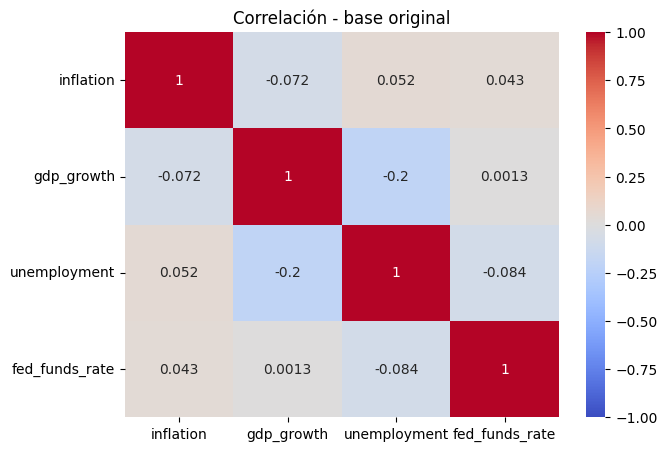


5) Faltantes por año
        inflation  gdp_growth  unemployment  fed_funds_rate
year                                                       
1960.0  30.434783  100.000000     97.101449             0.0
1961.0  28.985507   14.492754     97.101449             0.0
1962.0  28.985507   11.594203     97.101449             0.0
1963.0  30.434783   11.594203     97.101449             0.0
1964.0  27.536232   11.594203     97.101449             0.0


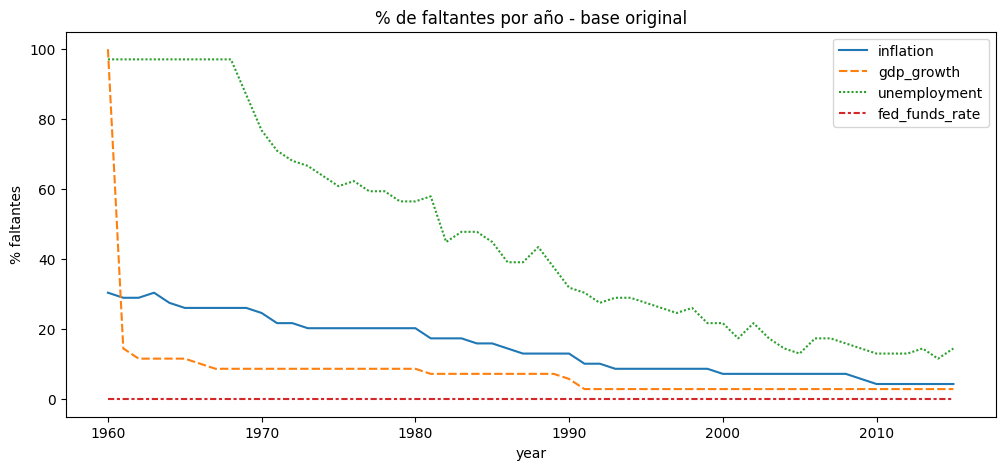


6) Países con variable completamente vacía (100% missing)
inflation         3
gdp_growth        2
unemployment      3
fed_funds_rate    0
dtype: int64

7) Resumen de variables con >50% missing por país
0    40
1    21
2     4
3     4
Name: count, dtype: int64

VALIDACIÓN DE SUPUESTOS - BASE FILTRADA

1) Dimensiones
(3416, 15)

2) Faltantes por variable
inflation          269
gdp_growth          74
unemployment      1443
fed_funds_rate       0
dtype: int64

3) Porcentaje de faltantes por variable
inflation          7.87
gdp_growth         2.17
unemployment      42.24
fed_funds_rate     0.00
dtype: float64

4) Correlación entre variables de estudio
                inflation  gdp_growth  unemployment  fed_funds_rate
inflation        1.000000   -0.079719      0.053194        0.045645
gdp_growth      -0.079719    1.000000     -0.220118        0.001601
unemployment     0.053194   -0.220118      1.000000       -0.085435
fed_funds_rate   0.045645    0.001601     -0.085435        1.000000


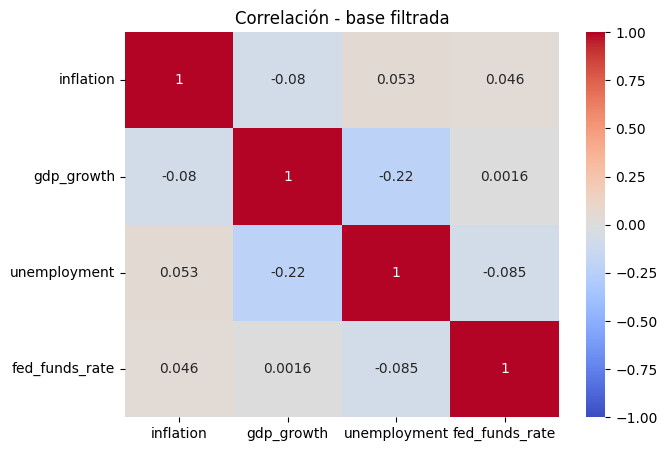


5) Faltantes por año
        inflation  gdp_growth  unemployment  fed_funds_rate
year                                                       
1960.0  21.311475  100.000000     96.721311             0.0
1961.0  19.672131    6.557377     96.721311             0.0
1962.0  19.672131    3.278689     96.721311             0.0
1963.0  21.311475    3.278689     96.721311             0.0
1964.0  18.032787    3.278689     96.721311             0.0


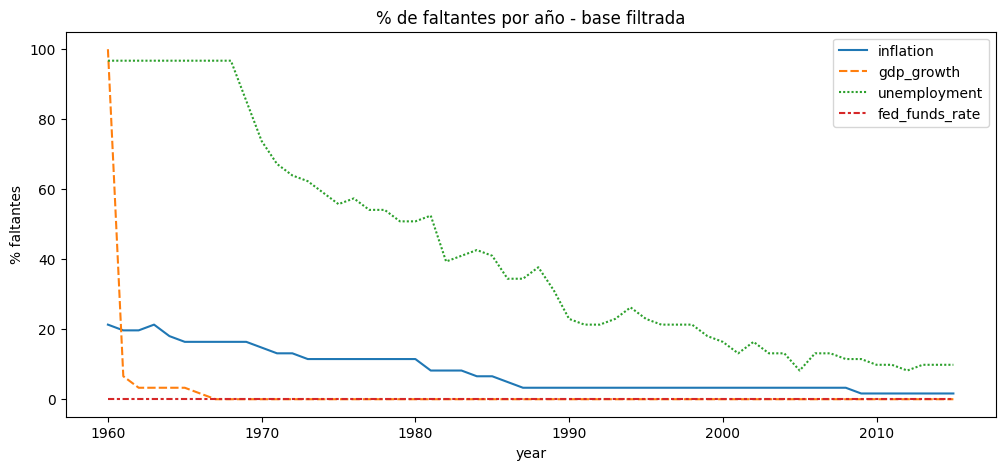


6) Países con variable completamente vacía (100% missing)
inflation         1
gdp_growth        0
unemployment      1
fed_funds_rate    0
dtype: int64

7) Resumen de variables con >50% missing por país
0    40
1    21
Name: count, dtype: int64


In [3]:
# -----------------------------
# 3. Validar supuestos para MICE
# -----------------------------
def validate_mice_assumptions(data, name="dataset"):
    print(f"\n{'='*60}")
    print(f"VALIDACIÓN DE SUPUESTOS - {name.upper()}")
    print(f"{'='*60}")
    
    print("\n1) Dimensiones")
    print(data.shape)
    
    print("\n2) Faltantes por variable")
    print(data[study_vars].isnull().sum())
    
    print("\n3) Porcentaje de faltantes por variable")
    print((data[study_vars].isnull().mean() * 100).round(2))
    
    print("\n4) Correlación entre variables de estudio")
    corr = data[study_vars].corr(numeric_only=True)
    print(corr)
    
    plt.figure(figsize=(7,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Correlación - {name}")
    plt.show()
    
    print("\n5) Faltantes por año")
    miss_year = data.groupby("year")[study_vars].apply(lambda x: x.isnull().mean() * 100)
    print(miss_year.head())
    
    plt.figure(figsize=(12,5))
    sns.lineplot(data=miss_year)
    plt.title(f"% de faltantes por año - {name}")
    plt.ylabel("% faltantes")
    plt.show()
    
    print("\n6) Países con variable completamente vacía (100% missing)")
    country_var_missing = data.groupby("iso3")[study_vars].apply(lambda x: x.isnull().mean())
    complete_missing = (country_var_missing == 1.0)
    print(complete_missing.sum())
    
    print("\n7) Resumen de variables con >50% missing por país")
    over50 = (country_var_missing > 0.5).sum(axis=1)
    print(over50.value_counts().sort_index())
    
    return {
        "corr": corr,
        "miss_year": miss_year,
        "country_var_missing": country_var_missing
    }

res_original = validate_mice_assumptions(df, name="base original")
res_filtered = validate_mice_assumptions(df_filtered, name="base filtrada")

In [4]:
# -----------------------------
# 4. Instalar / importar sklearn
# -----------------------------
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

FUNCION DE IMPUTACION MICE

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def run_mice_panel(data, study_vars, country_col="iso3", time_col="year", random_state=0, max_iter=20):
    data = data.copy()
    
    # guardar máscara original de faltantes
    missing_mask = data[study_vars].isnull()
    
    # dummies de país
    country_dummies = pd.get_dummies(data[country_col], prefix=country_col, drop_first=False)
    
    # matriz para imputación: variables estudio + año + país
    X = pd.concat(
        [
            data[[time_col] + study_vars],
            country_dummies
        ],
        axis=1
    )
    
    imputer = IterativeImputer(
        max_iter=max_iter,
        random_state=random_state,
        sample_posterior=False
    )
    
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    # reemplazar solo variables de estudio
    data_imputed = data.copy()
    data_imputed[study_vars] = X_imputed[study_vars]
    
    return data_imputed, missing_mask, X, X_imputed

In [9]:
# -----------------------------
# 5. Función MICE para panel
# -----------------------------
def run_mice_panel(data, study_vars, country_col="iso3", time_col="year", random_state=0, max_iter=20):
    data = data.copy()
    
    missing_mask = data[study_vars].isnull()
    
    country_dummies = pd.get_dummies(data[country_col], prefix=country_col, drop_first=False)
    
    X = pd.concat(
        [
            data[[time_col] + study_vars],
            country_dummies
        ],
        axis=1
    )
    
    imputer = IterativeImputer(
        max_iter=max_iter,
        random_state=random_state,
        sample_posterior=False
    )
    
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    data_imputed = data.copy()
    data_imputed[study_vars] = X_imputed[study_vars]
    
    return data_imputed, missing_mask, X, X_imputed

In [ ]:
# -----------------------------
# 6. Extraer solo valores imputados
# -----------------------------
def extract_imputed_values(original_df, imputed_df, study_vars):
    out = {}
    for var in study_vars:
        mask = original_df[var].isnull()
        out[var] = imputed_df.loc[mask, var]
    return out

imputed_values_orig = extract_imputed_values(df, df_imputed_orig, study_vars)
imputed_values_filt = extract_imputed_values(df_filtered, df_imputed_filt, study_vars)

In [ ]:
# -----------------------------
# 7. Mostrar ejemplos de valores imputados
# -----------------------------
for var in study_vars:
    print(f"\n{var} - base original")
    print(imputed_values_orig[var].head())

for var in study_vars:
    print(f"\n{var} - base filtrada")
    print(imputed_values_filt[var].head())


inflation - base original
0    28.565547
1    24.561345
2    27.354843
3    29.172433
4    30.485244
Name: inflation, dtype: float64

gdp_growth - base original
0    5.968257
1    6.035657
2    5.929618
3    5.848479
4    5.780219
Name: gdp_growth, dtype: float64

unemployment - base original
0    11.249060
1    11.164413
2    11.306248
3    11.415568
4    11.508070
Name: unemployment, dtype: float64

fed_funds_rate - base original
Series([], Name: fed_funds_rate, dtype: float64)

inflation - base filtrada
56    19.313218
57     9.113922
58    41.311821
59    63.946502
60    -9.165396
Name: inflation, dtype: float64

gdp_growth - base filtrada
56     4.057533
112    4.871704
168    4.285489
224    4.094308
280    5.313866
Name: gdp_growth, dtype: float64

unemployment - base filtrada
56    6.072859
57    5.721058
58    7.158098
59    8.185920
60    5.020456
Name: unemployment, dtype: float64

fed_funds_rate - base filtrada
Series([], Name: fed_funds_rate, dtype: float64)


In [18]:
# ---------------------------------------------------------
# 1. Verificar que no queden faltantes
# ---------------------------------------------------------
print("=== FALTANTES DESPUÉS DE MICE ===\n")

print("Base original imputada:")
print(df_imputed_orig[study_vars].isnull().sum())

print("\nBase filtrada imputada:")
print(df_imputed_filt[study_vars].isnull().sum())


=== FALTANTES DESPUÉS DE MICE ===

Base original imputada:
inflation         0
gdp_growth        0
unemployment      0
fed_funds_rate    0
dtype: int64

Base filtrada imputada:
inflation         0
gdp_growth        0
unemployment      0
fed_funds_rate    0
dtype: int64


In [19]:
# ---------------------------------------------------------
# 2. Función para construir resumen estadístico
# ---------------------------------------------------------
def build_validation_summary(original_df, imputed_df, study_vars, base_name):
    summary = pd.DataFrame({
        "variable": study_vars,
        "mean_original": original_df[study_vars].mean().values,
        "mean_imputed": imputed_df[study_vars].mean().values,
        "std_original": original_df[study_vars].std().values,
        "std_imputed": imputed_df[study_vars].std().values,
        "min_original": original_df[study_vars].min().values,
        "min_imputed": imputed_df[study_vars].min().values,
        "max_original": original_df[study_vars].max().values,
        "max_imputed": imputed_df[study_vars].max().values
    })
    
    summary["diff_mean"] = summary["mean_imputed"] - summary["mean_original"]
    summary["diff_std"] = summary["std_imputed"] - summary["std_original"]
    summary["base"] = base_name
    
    return summary


In [20]:
# ---------------------------------------------------------
# 3. Resumen para ambas bases
# ---------------------------------------------------------
summary_orig = build_validation_summary(df, df_imputed_orig, study_vars, "Original")
summary_filt = build_validation_summary(df_filtered, df_imputed_filt, study_vars, "Filtrada")

summary_all = pd.concat([summary_orig, summary_filt], ignore_index=True)

print("\n=== RESUMEN ESTADÍSTICO BASE ORIGINAL ===\n")
print(summary_orig.round(4))

print("\n=== RESUMEN ESTADÍSTICO BASE FILTRADA ===\n")
print(summary_filt.round(4))


=== RESUMEN ESTADÍSTICO BASE ORIGINAL ===

         variable  mean_original  mean_imputed  std_original  std_imputed  \
0       inflation        26.5215       27.3901      280.3265     258.7796   
1      gdp_growth         3.8777        3.8912        4.4380       4.2773   
2    unemployment         7.3616        7.1675        4.6239       4.4474   
3  fed_funds_rate         5.2555        5.2555        3.5463       3.5463   

   min_original  min_imputed  max_original  max_imputed  diff_mean  diff_std  \
0       -8.4225    -145.5105    11749.6396   11749.6396     0.8686  -21.5470   
1      -36.3920     -36.3920       42.4104      42.4104     0.0134   -0.1607   
2        0.1900      -1.1647       31.8400      31.8400    -0.1941   -0.1765   
3        0.0900       0.0900       16.3900      16.3900     0.0000    0.0000   

       base  
0  Original  
1  Original  
2  Original  
3  Original  

=== RESUMEN ESTADÍSTICO BASE FILTRADA ===

         variable  mean_original  mean_imputed  std_ori

In [21]:
# ---------------------------------------------------------
# 4. Comparación de correlaciones
# ---------------------------------------------------------
corr_orig_before = df[study_vars].corr()
corr_orig_after = df_imputed_orig[study_vars].corr()

corr_filt_before = df_filtered[study_vars].corr()
corr_filt_after = df_imputed_filt[study_vars].corr()

print("\n=== CORRELACIÓN BASE ORIGINAL ANTES ===\n")
print(corr_orig_before.round(4))

print("\n=== CORRELACIÓN BASE ORIGINAL DESPUÉS ===\n")
print(corr_orig_after.round(4))

print("\n=== CORRELACIÓN BASE FILTRADA ANTES ===\n")
print(corr_filt_before.round(4))

print("\n=== CORRELACIÓN BASE FILTRADA DESPUÉS ===\n")
print(corr_filt_after.round(4))



=== CORRELACIÓN BASE ORIGINAL ANTES ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0719        0.0515          0.0428
gdp_growth        -0.0719      1.0000       -0.1983          0.0013
unemployment       0.0515     -0.1983        1.0000         -0.0839
fed_funds_rate     0.0428      0.0013       -0.0839          1.0000

=== CORRELACIÓN BASE ORIGINAL DESPUÉS ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0813        0.0664          0.0460
gdp_growth        -0.0813      1.0000       -0.2337         -0.0077
unemployment       0.0664     -0.2337        1.0000          0.0044
fed_funds_rate     0.0460     -0.0077        0.0044          1.0000

=== CORRELACIÓN BASE FILTRADA ANTES ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0797        0.0532          0.0456
gdp_growth        -0.0797      1.0000       -0.2201     

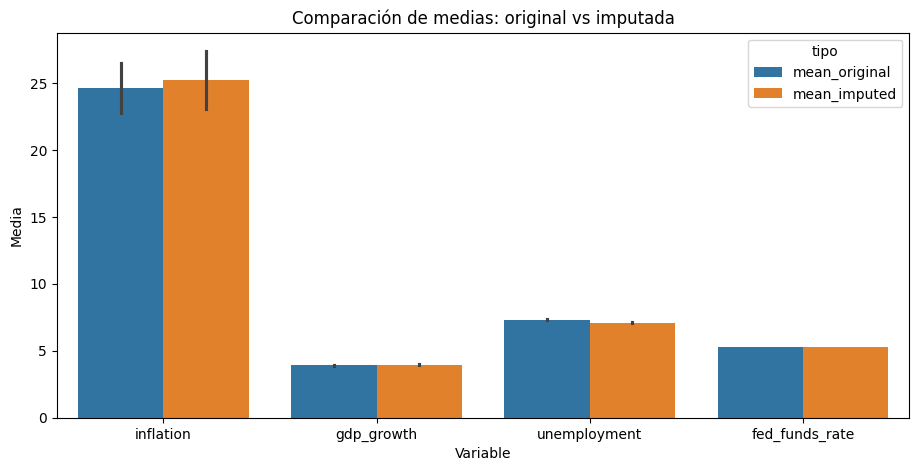

In [ ]:
# ---------------------------------------------------------
# 5. Gráfica 3: medias original vs imputada
# ---------------------------------------------------------
plot_means = pd.concat([
    summary_orig[["variable", "mean_original", "mean_imputed"]].assign(base="Original"),
    summary_filt[["variable", "mean_original", "mean_imputed"]].assign(base="Filtrada")
], ignore_index=True)

plot_means_long = plot_means.melt(
    id_vars=["variable", "base"],
    value_vars=["mean_original", "mean_imputed"],
    var_name="tipo",
    value_name="media"
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_means_long,
    x="variable",
    y="media",
    hue="tipo"
)
plt.title("Comparación de medias: original vs imputada")
plt.ylabel("Media")
plt.xlabel("Variable")
plt.show()


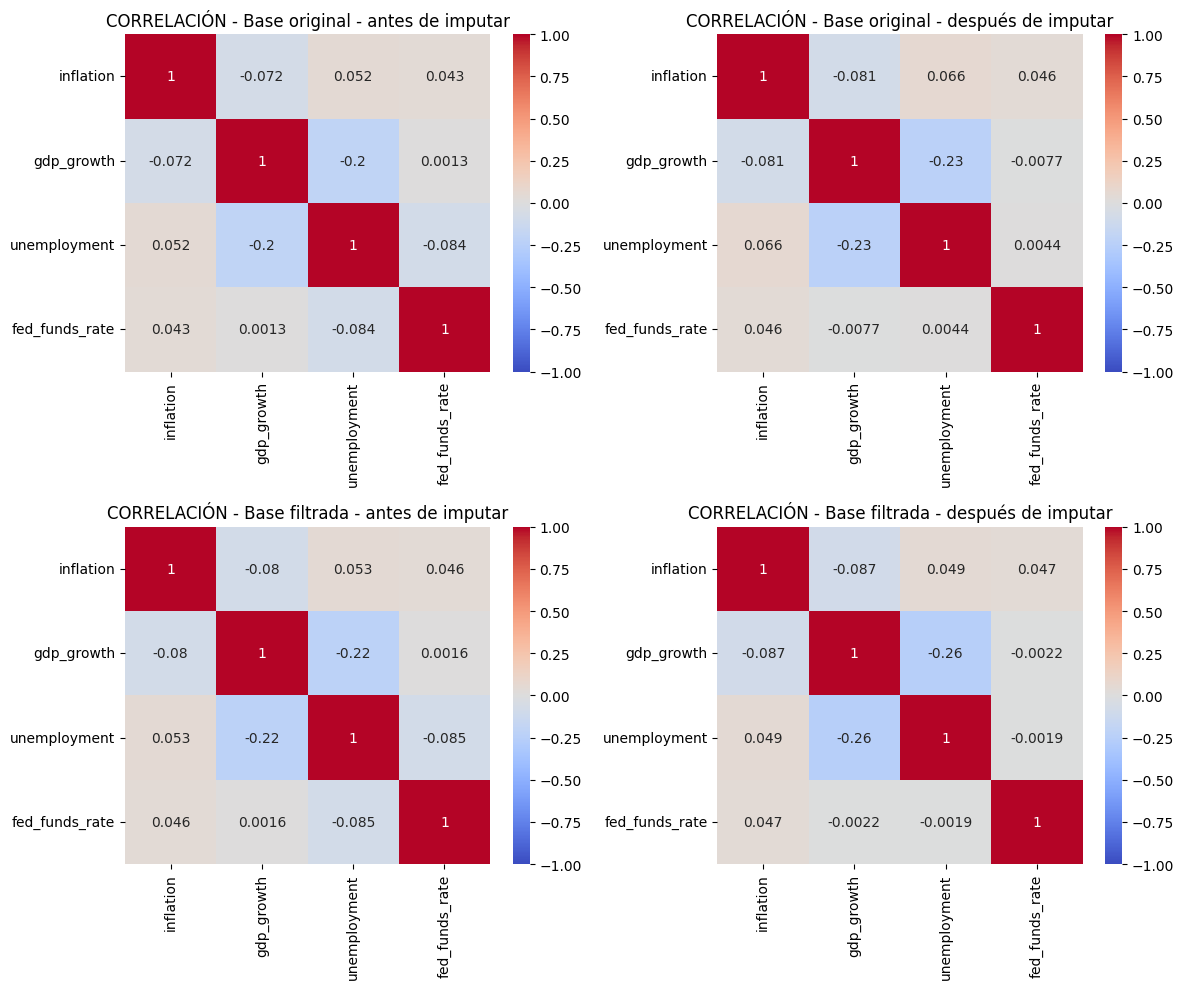

In [ ]:
# ---------------------------------------------------------
# 6. Gráfica 5: heatmaps de correlación lado a lado
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(corr_orig_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0, 0])
axes[0, 0].set_title("CORRELACIÓN - Base original - antes de imputar")

sns.heatmap(corr_orig_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title("CORRELACIÓN - Base original - después de imputar")

sns.heatmap(corr_filt_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title("CORRELACIÓN - Base filtrada - antes de imputar")

sns.heatmap(corr_filt_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("CORRELACIÓN - Base filtrada - después de imputar")

plt.tight_layout()
plt.show()


In [29]:
import pandas as pd
import numpy as np

study_vars = ["inflation","gdp_growth","unemployment","fed_funds_rate"]

def outliers_by_country(df, study_vars):

    results = []

    for var in study_vars:

        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # detectar outliers
        df["outlier_flag"] = ((df[var] < lower) | (df[var] > upper)).astype(int)

        country_outliers = df.groupby("iso3")["outlier_flag"].agg(["sum","count"]).reset_index()

        country_outliers["variable"] = var
        country_outliers["pct_outliers"] = (country_outliers["sum"] / country_outliers["count"]) * 100

        country_outliers.rename(columns={
            "sum":"n_outliers",
            "count":"n_obs"
        }, inplace=True)

        results.append(country_outliers)

    final_table = pd.concat(results)

    final_table = final_table[final_table["n_outliers"] > 0]

    final_table = final_table.sort_values("n_outliers", ascending=False)

    return final_table

In [32]:
outliers_original_table = outliers_by_country(df, study_vars)

outliers_original_table = outliers_original_table.sort_values(
    by=["iso3","variable"]
)

print("OUTLIERS POR PAÍS - BASE ORIGINAL")
print(outliers_original_table)

OUTLIERS POR PAÍS - BASE ORIGINAL
   iso3  n_outliers  n_obs        variable  pct_outliers
0   AGO           1     56  fed_funds_rate      1.785714
0   AGO           7     56      gdp_growth     12.500000
0   AGO          14     56       inflation     25.000000
0   AGO           2     56    unemployment      3.571429
1   ARG           1     56  fed_funds_rate      1.785714
..  ...         ...    ...             ...           ...
67  ZMB           3     56      gdp_growth      5.357143
67  ZMB          13     56       inflation     23.214286
67  ZMB           2     56    unemployment      3.571429
68  ZWE           1     56  fed_funds_rate      1.785714
68  ZWE          14     56      gdp_growth     25.000000

[166 rows x 5 columns]


In [34]:
outliers_filtered_table = outliers_by_country(df_filtered, study_vars)

outliers_filtered_table = outliers_filtered_table.sort_values(
    by=["iso3","variable"]
)

print("OUTLIERS POR PAÍS - BASE FILTRADA")
print(outliers_filtered_table)

OUTLIERS POR PAÍS - BASE FILTRADA
   iso3  n_outliers  n_obs        variable  pct_outliers
0   ARG           1     56  fed_funds_rate      1.785714
0   ARG           8     56      gdp_growth     14.285714
0   ARG           3     56    unemployment      5.357143
1   AUS           1     56  fed_funds_rate      1.785714
2   AUT           1     56  fed_funds_rate      1.785714
..  ...         ...    ...             ...           ...
59  ZAF          18     56    unemployment     32.142857
60  ZMB           1     56  fed_funds_rate      1.785714
60  ZMB           4     56      gdp_growth      7.142857
60  ZMB          13     56       inflation     23.214286
60  ZMB           2     56    unemployment      3.571429

[150 rows x 5 columns]
